# Batch Cost Escalation, all steps performs
Data manipulation

Descriptive & inferential statistics

Model building

Model interpretation (technical + business)

result validation, best-model selection, stability

Standard libraries, I have imported, and used for this use case: **pandas** (tables), **matplotlib / seaborn** (charts), **scipy** (statistical tests), **scikit-learn** (models).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

RANDOM_STATE = 42
LEVELS = ["Normal", "Watch", "High", "Critical"]     # target levels
COLORS = ["#4C9F70", "#E3B23C", "#E07A1F", "#C0392B"]

Data Manipulation step

In [2]:
prod = pd.read_csv("production_batches.csv")
supp = pd.read_csv("supplier_quality.csv")

In [3]:
prod.head()

,Batch_ID,Production_Date,Plant_ID,Product_Category,Supplier_ID,Shift,Batch_Size,Planned_Cost,Scrap_Rate,Rework_Hours,Machine_Downtime_Hours,Energy_Consumption_kWh,Temperature_C,Post_Overrun_Amount,Post_Inspection_Score,Post_Warranty_Claim_Flag,Cost_Escalation_Level
0,B004711,2025-08-06,PLT10,C,SUP0044,Day,1100,158002.85,0.0860,2.90,3.04,1451.9,22.3,15318.69,77.0,0,Normal
1,B000692,2025-03-21,PLT01,C,SUP0049,Day,967,136356.33,0.1125,7.32,3.63,1207.8,26.9,17850.11,72.2,0,Normal
2,B000066,2025-02-22,PLT06,C,SUP0087,Night,1590,205014.20,0.1359,10.43,2.40,1808.6,23.0,48087.16,48.9,0,High
3,B003427,2025-08-17,PLT02,C,SUP0055,Day,1266,187496.65,0.1098,1.93,6.54,1608.8,29.6,33987.51,74.7,0,Watch
4,B004821,2025-11-23,PLT02,B,SUP0037,Day,1459,169309.75,0.1093,2.33,2.48,1497.6,NaN,23920.04,77.4,0,Normal


In [ ]:
supp.head()

,Supplier_ID,Product_Category,Month,Defect_Rate,On_Time_Delivery_Rate,Avg_Lead_Time_Days,Supplier_Risk_Score,Audit_Flag
0,SUP0001,B,1,0.051102,0.781730,17.313614,44.246281,Pass
1,SUP0001,B,2,0.048187,0.818876,21.007226,37.811430,Pass
2,SUP0001,B,3,0.025585,0.858922,15.077467,28.332672,Pass
3,SUP0001,B,4,0.038698,0.789583,13.733378,38.121440,Fail
4,SUP0001,B,5,0.039243,0.798484,10.108538,29.306913,Pass


In [4]:
print("Production batches:", prod.shape)
print("Supplier quality  :", supp.shape)

Production batches: (5050, 17)
Supplier quality  : (3780, 8)


Now, I am checking Data quality checks: **missing values**, **duplicate rows**, **inconsistent text values**, and **impossible values**.

In [5]:
print("Missing values in production file:")
print(prod.isna().sum()[prod.isna().sum() > 0])
print()

Missing values in production file:
Rework_Hours               41
Machine_Downtime_Hours     48
Energy_Consumption_kWh     75
Temperature_C             205
dtype: int64



In [6]:
print("Missing values in supplier file:")
print(supp.isna().sum()[supp.isna().sum() > 0])

Missing values in supplier file:
Defect_Rate     84
Audit_Flag     103
dtype: int64


In [7]:
print("duplicated rows:", prod.duplicated().sum())
print("Repeated Batch_IDs:", prod["Batch_ID"].duplicated().sum())

duplicated rows: 47
Repeated Batch_IDs: 50


In [8]:
# I check supplier ids should look like 'SUP0001'. some have extra spaces or lower-case letters.
bad_ids = prod[prod["Supplier_ID"] != prod["Supplier_ID"].str.strip().str.upper()]["Supplier_ID"]
print("Badly formatted Supplier_IDs:", len(bad_ids))

Badly formatted Supplier_IDs: 243


In [9]:
print(bad_ids.unique()[:8])

['SUP0055 ' 'sup0108' 'SUP0174 ' 'sup0056' 'SUP0083 ' 'SUP0019 '
 'SUP0169 ' 'SUP0112 ']


In [10]:
# range check: min and max of every numeric column (looking for impossible values)
prod.describe().T[["min", "50%", "max"]].round(2)

,min,50%,max
Batch_Size,390.00,1350.00,4766.00
Planned_Cost,35597.84,161595.21,825042.71
Scrap_Rate,0.00,0.09,0.24
Rework_Hours,0.12,4.50,30.69
Machine_Downtime_Hours,0.05,3.63,39.56
Energy_Consumption_kWh,326.10,1384.10,7005.90
Temperature_C,12.00,27.50,48.00
Post_Overrun_Amount,-958.98,24612.90,741570.28
Post_Inspection_Score,40.50,74.30,100.00
Post_Warranty_Claim_Flag,0.00,0.00,1.00


**My findings**
* **Missing values are small**
* **47 rows are exact duplicates**
* **3 more Batch_IDs appear twice**:
* **243 Supplier_IDs are badly formatted** (for example "SUP0055 " with a trailing space, or "sup0157" in lower case).

Data Cleaning

In [13]:
# fix the Supplier_ID format: remove spaces, make upper-case
prod["Supplier_ID"] = prod["Supplier_ID"].str.strip().str.upper()

# remove exact duplicate rows
prod = prod.drop_duplicates()

# for the 3 Batch_IDs that still appear twice, drop the copy with the blank Energy value
repeated = prod["Batch_ID"].duplicated(keep=False)
prod = prod[~(repeated & prod["Energy_Consumption_kWh"].isna())]

In [14]:
# get the month from the date (needed to join the monthly supplier scorecard)
prod["Production_Date"] = pd.to_datetime(prod["Production_Date"])
prod["Month"] = prod["Production_Date"].dt.month

print("Batches after cleaning:", len(prod), "| unique Batch_IDs:", prod["Batch_ID"].nunique())

Batches after cleaning: 5000 | unique Batch_IDs: 5000


Merge production with supplier quality:
The supplier file has one row per **Supplier id + Product_Category + Month**, so we join on these 3 columns..

In [15]:
print("Is the supplier key unique?", not supp.duplicated(["Supplier_ID", "Product_Category", "Month"]).any())

df = prod.merge(supp, on=["Supplier_ID", "Product_Category", "Month"], how="left")
df["Audit_Flag"] = df["Audit_Flag"].fillna("Unknown")

Is the supplier key unique? True


In [16]:
print("Rows before merge:", len(prod), "| rows after merge:", len(df))
print("Batches with no supplier scorecard:", df["Supplier_Risk_Score"].isna().sum())

Rows before merge: 5000 | rows after merge: 5000
Batches with no supplier scorecard: 253


Descriptive & Inferential Statistics

The target: column

In [17]:
counts = df["Cost_Escalation_Level"].value_counts().reindex(LEVELS)
print((counts / counts.sum() * 100).round(1).astype(str) + " %")

Cost_Escalation_Level
Normal      60.0 %
Watch       20.0 %
High        13.0 %
Critical     7.1 %
Name: count, dtype: object


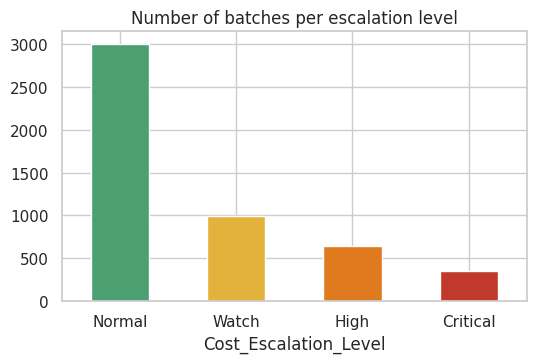

In [18]:
counts.plot(kind="bar", color=COLORS, figsize=(6, 3.5), title="Number of batches per escalation level")
plt.xticks(rotation=0); plt.show()

The classes are imbalanced.** 60% of batches are Normal and only 7% are Critical. The model that always says *Normal* would be 60%. Because of this: i am using models by **macro-F1** (the average F1 score of the 4 levels, each level counts equally), not by accuracy;

How is the target defined?
We use the 'Post_Overrun_Amount' column **only to understand** the label (not as a model input).

In [19]:
df["Overrun_Pct"] = df["Post_Overrun_Amount"] / df["Planned_Cost"] * 100

print(df.groupby("Cost_Escalation_Level")["Overrun_Pct"].median().reindex(LEVELS).round(1))

Cost_Escalation_Level
Normal      12.7
Watch       17.9
High        21.4
Critical    26.2
Name: Overrun_Pct, dtype: float64


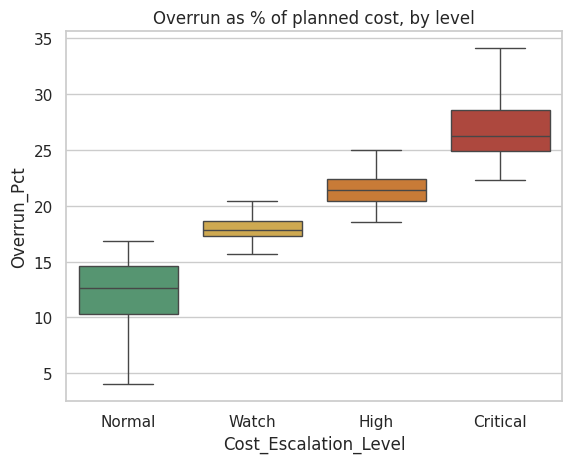

In [20]:
sns.boxplot(data=df, x="Cost_Escalation_Level", y="Overrun_Pct", order=LEVELS, palette=COLORS, showfliers=False)
plt.title("Overrun as % of planned cost, by level"); plt.show()

Which numbers differ between the levels?
We compare the **median** of each numeric column for each level.

In [21]:
NUMERIC = ["Batch_Size", "Planned_Cost", "Scrap_Rate", "Rework_Hours", "Machine_Downtime_Hours",
           "Energy_Consumption_kWh", "Temperature_C",
           "Defect_Rate", "On_Time_Delivery_Rate", "Avg_Lead_Time_Days", "Supplier_Risk_Score"]

In [22]:
df.groupby("Cost_Escalation_Level")[NUMERIC].median().reindex(LEVELS).T.round(3)

Cost_Escalation_Level,Normal,Watch,High,Critical
Batch_Size,1357.500,1348.000,1335.000,1321.500
Planned_Cost,162513.115,160067.415,154462.155,165250.680
Scrap_Rate,0.082,0.094,0.101,0.107
Rework_Hours,4.180,4.825,5.200,4.990
Machine_Downtime_Hours,2.670,4.630,6.475,10.170
Energy_Consumption_kWh,1365.450,1380.400,1385.350,1485.100
Temperature_C,27.800,27.200,27.500,26.700
Defect_Rate,0.043,0.047,0.050,0.054
On_Time_Delivery_Rate,0.759,0.733,0.715,0.696
Avg_Lead_Time_Days,17.003,18.212,18.536,19.396


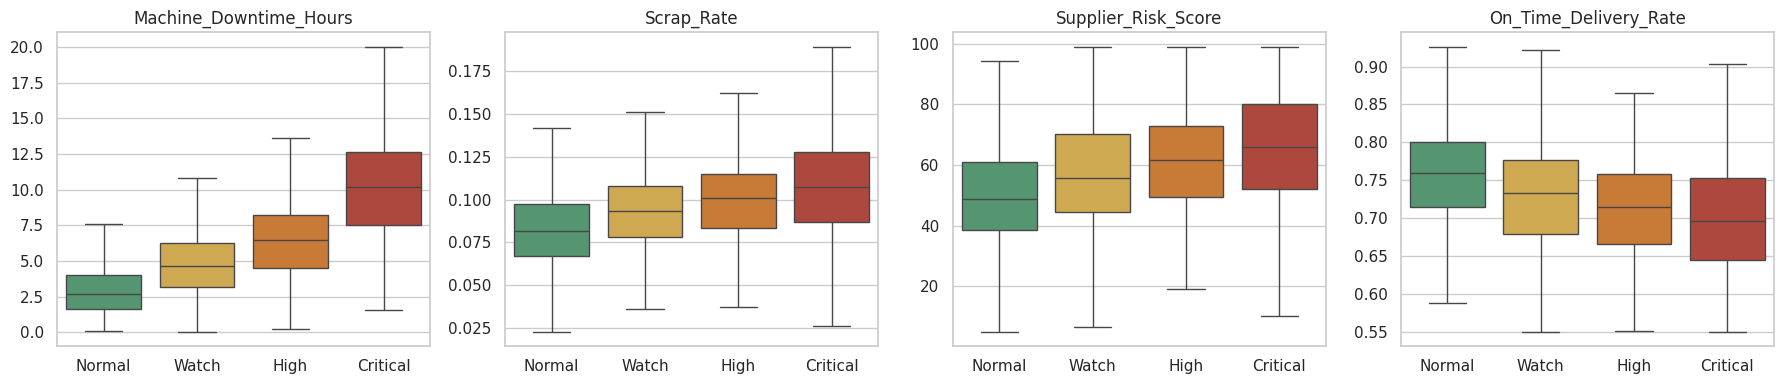

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ["Machine_Downtime_Hours", "Scrap_Rate", "Supplier_Risk_Score", "On_Time_Delivery_Rate"]):
    sns.boxplot(data=df, x="Cost_Escalation_Level", y=col, order=LEVELS, palette=COLORS, showfliers=False, ax=ax)
    ax.set_title(col); ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

Which categories have more High/Critical batches?
For each category we show the **% of batches that are High or Critical** (the expensive ones).

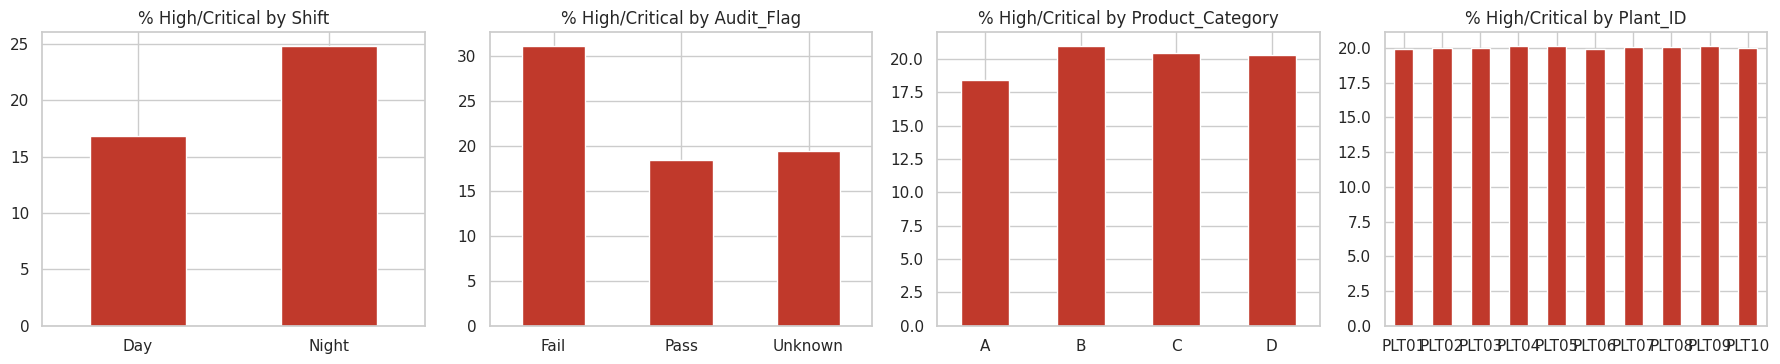

In [24]:
df["High_or_Critical"] = df["Cost_Escalation_Level"].isin(["High", "Critical"]).astype(int)

fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, col in zip(axes, ["Shift", "Audit_Flag", "Product_Category", "Plant_ID"]):
    rate = df.groupby(col)["High_or_Critical"].mean() * 100
    rate.plot(kind="bar", ax=ax, color="#C0392B")
    ax.set_title(f"% High/Critical by {col}"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

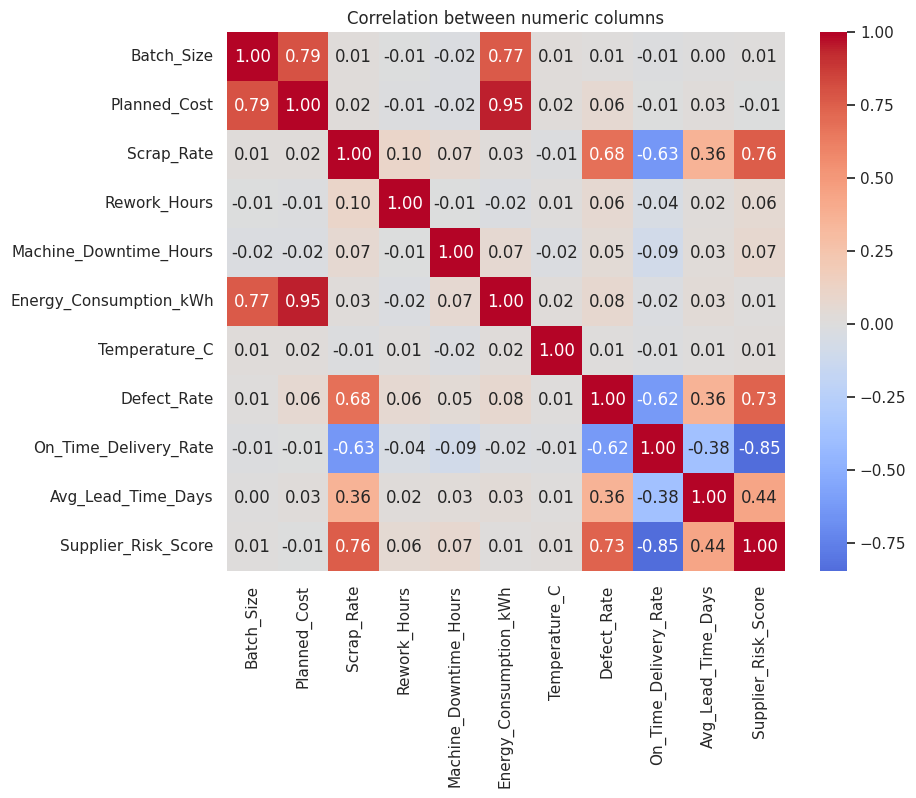

In [25]:
# correlation between the numeric columns
plt.figure(figsize=(9, 7))
sns.heatmap(df[NUMERIC].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between numeric columns"); plt.show()

Inferential statistics: are these differences real or just chance?
Descriptive differences could be random noise. We use **hypothesis tests** to check.

| Column type | Test | Null hypothesis (H0) |
|---|---|---|
| Numeric (e.g. downtime) | **Kruskal–Wallis** | The column has the same distribution in all 4 levels |
| Categorical (e.g. shift) | **Chi-square** | The escalation mix is the same for every category |

* If **p-value < 0.05**, we reject H0: the difference is statistically significant.
* We use **Kruskal–Wallis instead of ANOVA** because our data is skewed

In [26]:
results = []

for col in NUMERIC:
    groups = [df.loc[df["Cost_Escalation_Level"] == lvl, col].dropna() for lvl in LEVELS]
    H, p = stats.kruskal(*groups)
    epsilon_sq = (H - 4 + 1) / (len(df) - 4) # effect size
    results.append([col, "Kruskal-Wallis", round(p, 4), round(epsilon_sq, 3)])

for col in ["Shift", "Audit_Flag", "Product_Category", "Plant_ID"]:
    table = pd.crosstab(df[col], df["Cost_Escalation_Level"])
    chi2, p, dof, expected = stats.chi2_contingency(table)
    cramers_v = np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1)))   # effect size
    results.append([col, "Chi-square", round(p, 4), round(cramers_v, 3)])

tests = pd.DataFrame(results, columns=["column", "test", "p_value", "effect_size"])
tests["significant"] = tests["p_value"] < 0.05
tests.sort_values("effect_size", ascending=False).reset_index(drop=True)

,column,test,p_value,effect_size,significant
0,Machine_Downtime_Hours,Kruskal-Wallis,0.0000,0.349,True
1,Shift,Chi-square,0.0000,0.131,True
2,Scrap_Rate,Kruskal-Wallis,0.0000,0.109,True
3,Audit_Flag,Chi-square,0.0000,0.095,True
4,Supplier_Risk_Score,Kruskal-Wallis,0.0000,0.082,True
5,On_Time_Delivery_Rate,Kruskal-Wallis,0.0000,0.075,True
6,Defect_Rate,Kruskal-Wallis,0.0000,0.060,True
7,Avg_Lead_Time_Days,Kruskal-Wallis,0.0000,0.037,True
8,Product_Category,Chi-square,0.2643,0.027,False
9,Rework_Hours,Kruskal-Wallis,0.0000,0.013,True


---
# Model Building

In [27]:
NUMERIC_FEATURES = NUMERIC  # total we have 11 numeric columns
CATEGORY_FEATURES = ["Plant_ID", "Product_Category", "Shift", "Audit_Flag"]
FEATURES = NUMERIC_FEATURES + CATEGORY_FEATURES

X = df[FEATURES]
y = df["Cost_Escalation_Level"].map({"Normal": 0, "Watch": 1, "High": 2, "Critical": 3})

print("Number of features:", len(FEATURES))

Number of features: 15


Split into training data and test data
**80% training**, **20% test**

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Training rows:", len(X_train), "| Test rows:", len(X_test))

Training rows: 4000 | Test rows: 1000


Quick experiment: what happens if we cheat (use the `Post_` columns)?

In [29]:
cheat_cols = ["Post_Overrun_Amount", "Post_Inspection_Score", "Post_Warranty_Claim_Flag", "Planned_Cost"]
cheat_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
cheat_model.fit(df.loc[X_train.index, cheat_cols], y_train)
cheat_pred = cheat_model.predict(df.loc[X_test.index, cheat_cols])
print("Macro-F1 using AFTER-production columns:", round(f1_score(y_test, cheat_pred, average="macro"), 3))

Macro-F1 using AFTER-production columns: 0.863


A score of ~0.87 looks great, but the model is just reading the answer (the overrun amount). In real life this value does not exist yet when we need the prediction. **This is why our honest model scores lower, and that is correct.**

Preparing the data for the models (pipeline)
Models need clean numbers, so each feature is prepared first:
* **Numeric:** fill missing values with the median, then scale (mean 0, std 1). Scaling is needed by Logistic Regression.
* **Categorical:** one-hot encoding (e.g. Shift → `Shift_Day`, `Shift_Night` as 0/1 columns).

We put the preparation and the model together in one **Pipeline**. Then the preparation is learned **only from training data**, which avoids leakage from the test data.

In [30]:
preprocess = ColumnTransformer([
    ("num", Pipeline([("fill_missing", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORY_FEATURES),
])

differnt models we can use

| Model | Why we try it |
|---|---|
| **Baseline** (always predicts "Normal") | The minimum bar: every real model must beat it |
| **Logistic Regression** | Simple, fast and easy to explain |
| **Random Forest** | Many decision trees voting together; captures non-linear patterns |
| **Gradient Boosting** | Trees built one after another, each fixing the previous errors; often the strongest on tables |

In [31]:
models = {
    "Baseline":            DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=5,
                                                  class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.05,
                                                      random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = []
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro")
    rows.append([name, scores.mean().round(3), scores.std().round(3)])

comparison = pd.DataFrame(rows, columns=["model", "cv_macro_f1_mean", "cv_macro_f1_std"])
comparison.sort_values("cv_macro_f1_mean", ascending=False)

,model,cv_macro_f1_mean,cv_macro_f1_std
1,Logistic Regression,0.544,0.012
2,Random Forest,0.539,0.022
3,Gradient Boosting,0.528,0.016
0,Baseline,0.188,0.000


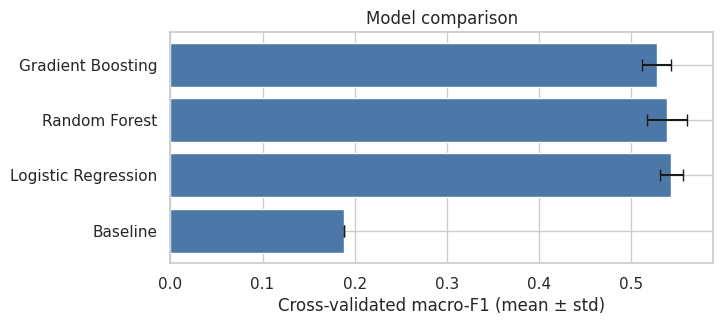

In [32]:
plt.figure(figsize=(7, 3))
plt.barh(comparison["model"], comparison["cv_macro_f1_mean"], xerr=comparison["cv_macro_f1_std"], color="#4C78A8", capsize=4)
plt.xlabel("Cross-validated macro-F1 (mean ± std)"); plt.title("Model comparison"); plt.show()

Which model do we pick?
* All 3 real models are far better than the baseline (≈ 0.53–0.54 vs 0.19).
* **Logistic Regression has the highest score (0.544)**. Random Forest (0.530) and Gradient Boosting (0.528) are not better; the gaps are smaller than the fold-to-fold noise (std ≈ 0.01–0.02).
* When scores are this close, we choose the **simplest model**: it is easier to explain, cheaper to run and less likely to overfit.

**Final model: Logistic Regression.** We now train it on the full training data.

In [33]:
final_model = Pipeline([("prep", preprocess),
                        ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))])
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test) # predictions on the hidden test data (used in Sections 4 and 5)

 Model Interpretation

Technical interpretation: which features does the model rely on?
**Permutation importance:** shuffle one feature at a time on the test data and measure how much the score drops.
A big drop means the model needs that feature.

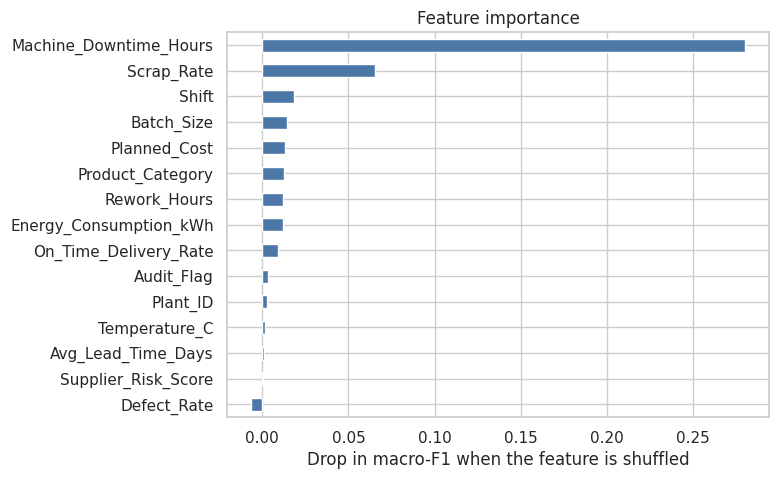

In [34]:
perm = permutation_importance(final_model, X_test, y_test, scoring="f1_macro", n_repeats=10, random_state=RANDOM_STATE)
importance = pd.Series(perm.importances_mean, index=FEATURES).sort_values()

importance.plot(kind="barh", figsize=(7, 5), color="#4C78A8")
plt.xlabel("Drop in macro-F1 when the feature is shuffled"); plt.title("Feature importance"); plt.show()

In [35]:
feature_names = final_model.named_steps["prep"].get_feature_names_out()
critical_coef = final_model.named_steps["model"].coef_[3]   # row 3 = "Critical"

odds = pd.Series(np.exp(critical_coef), index=feature_names).sort_values(ascending=False)
odds.head(6).round(2)

,0
num__Machine_Downtime_Hours,8.23
num__Scrap_Rate,2.32
cat__Plant_ID_PLT10,1.83
cat__Shift_Night,1.66
num__Avg_Lead_Time_Days,1.45
num__Rework_Hours,1.41


Business interpretation: what does this mean in money and actions?

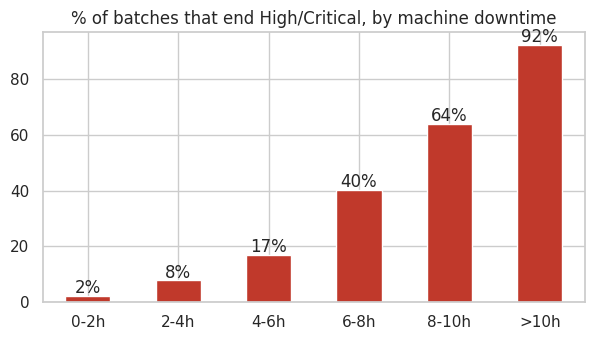

In [36]:
df["Downtime_band"] = pd.cut(df["Machine_Downtime_Hours"], [0, 2, 4, 6, 8, 10, 100],
                             labels=["0-2h", "2-4h", "4-6h", "6-8h", "8-10h", ">10h"])

rate = df.groupby("Downtime_band")["High_or_Critical"].mean() * 100
ax = rate.plot(kind="bar", color="#C0392B", figsize=(7, 3.5))
for i, v in enumerate(rate):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center")
plt.title("% of batches that end High/Critical, by machine downtime"); plt.xticks(rotation=0); plt.xlabel(""); plt.show()

In [37]:
# how much money sits in each level? (actual overruns, used here for sizing only, not for prediction)
money = df.groupby("Cost_Escalation_Level")["Post_Overrun_Amount"].agg(["count", "mean", "sum"]).reindex(LEVELS)
money.columns = ["batches", "avg_overrun_$", "total_overrun_$"]
money.round(0)

,batches,avg_overrun_$,total_overrun_$
Cost_Escalation_Level,,,
Normal,3000,24172.0,72515679.0
Watch,998,32194.0,32129875.0
High,648,40646.0,26338488.0
Critical,354,51026.0,18063270.0


In [38]:
# On the test data: how much of the overrun money is in the batches the model flags as High/Critical?
test = df.loc[X_test.index].copy()
test["flagged"] = y_pred >= 2                                 # 2 = High, 3 = Critical

print("Batches flagged High/Critical:", f"{test['flagged'].mean():.0%}", "of test batches")
print("Share of total overrun $ in those batches:",
      f"{test.loc[test['flagged'], 'Post_Overrun_Amount'].sum() / test['Post_Overrun_Amount'].sum():.0%}")
print("Average overrun: flagged", f"${test.loc[test['flagged'], 'Post_Overrun_Amount'].mean():,.0f}",
      "vs not flagged", f"${test.loc[~test['flagged'], 'Post_Overrun_Amount'].mean():,.0f}")

Batches flagged High/Critical: 24% of test batches
Share of total overrun $ in those batches: 36%
Average overrun: flagged $44,662 vs not flagged $24,986


Result validation on the hidden test data

In [39]:
print(classification_report(y_test, y_pred, target_names=LEVELS, digits=3))

              precision    recall  f1-score   support

      Normal      0.882     0.750     0.811       600
       Watch      0.359     0.445     0.397       200
        High      0.404     0.488     0.442       129
    Critical      0.616     0.746     0.675        71

    accuracy                          0.655      1000
   macro avg      0.565     0.607     0.581      1000
weighted avg      0.697     0.655     0.671      1000



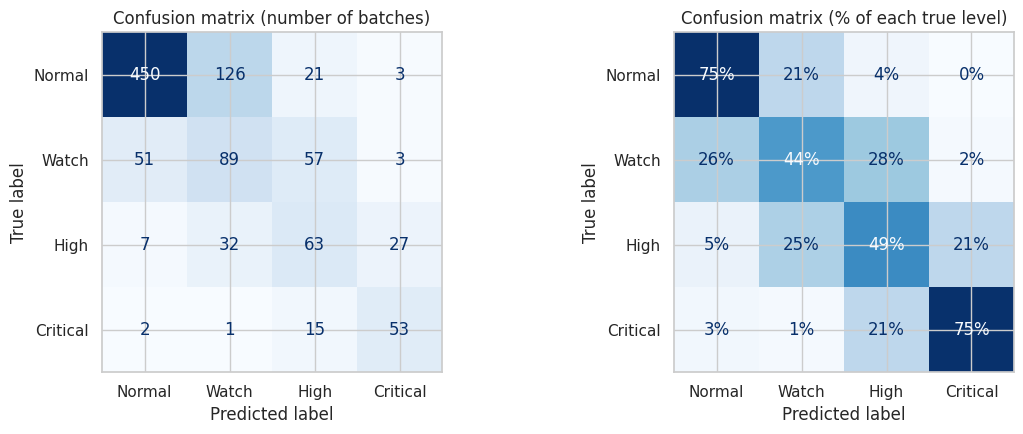

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=LEVELS).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix (number of batches)")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"), display_labels=LEVELS).plot(
    ax=axes[1], cmap="Blues", colorbar=False, values_format=".0%")
axes[1].set_title("Confusion matrix (% of each true level)")
plt.tight_layout(); plt.show()

In [41]:
baseline_pred = np.zeros(len(y_test))  # always "Normal"
true_risky, pred_risky = (y_test >= 2), (y_pred >= 2) # High or Critical

print("Test macro-F1               :", round(f1_score(y_test, y_pred, average="macro"), 3))
print("Baseline macro-F1           :", round(f1_score(y_test, baseline_pred, average="macro"), 3))
print("Accuracy                    :", round(accuracy_score(y_test, y_pred), 3))
print("Correct or off by one level :", round((abs(y_test - y_pred) <= 1).mean(), 3))
print("High/Critical batches caught:", round((true_risky & pred_risky).sum() / true_risky.sum(), 3))
print("High/Critical alerts correct:", round((true_risky & pred_risky).sum() / pred_risky.sum(), 3))

Test macro-F1               : 0.581
Baseline macro-F1           : 0.188
Accuracy                    : 0.655
Correct or off by one level : 0.963
High/Critical batches caught: 0.79
High/Critical alerts correct: 0.653


How do we make sure the model is stable and predictable?
We check 3 things:

| Check | Question it answers |
|---|---|
| **Repeated cross-validation** (5 folds × 5 repeats = 25 scores) | Does the score depend on a lucky split? |
| **Out-of-time test** (train Jan–Sep, test Oct–Dec) | Does a model built on the past predict the future? |
| **Segment check** (by shift and product category) | Does it work equally well for every part of the business? |

In [42]:
repeated_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
scores = cross_val_score(final_model, X_train, y_train, cv=repeated_cv, scoring="f1_macro")

print(f"25 scores -> mean {scores.mean():.3f} | std {scores.std():.3f} | min {scores.min():.3f} | max {scores.max():.3f}")

25 scores -> mean 0.541 | std 0.018 | min 0.507 | max 0.589


In [43]:
past   = df["Month"] <= 9  # Jan - Sep
future = df["Month"] >= 10 # Oct - Dec

time_model = Pipeline([("prep", preprocess),
                       ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))])
time_model.fit(X[past], y[past])
future_pred = time_model.predict(X[future])

print("Trained on", past.sum(), "batches (Jan-Sep), tested on", future.sum(), "batches (Oct-Dec)")
print("Out-of-time macro-F1:", round(f1_score(y[future], future_pred, average="macro"), 3))

Trained on 3776 batches (Jan-Sep), tested on 1224 batches (Oct-Dec)
Out-of-time macro-F1: 0.512


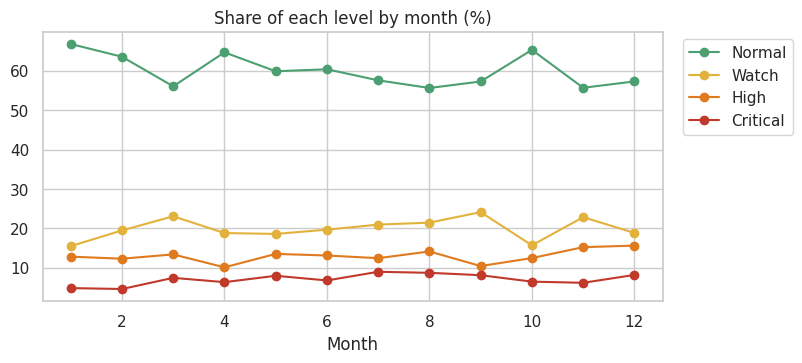

In [44]:
# is the escalation mix stable month by month?
monthly = pd.crosstab(df["Month"], df["Cost_Escalation_Level"], normalize="index")[LEVELS] * 100
monthly.plot(marker="o", color=COLORS, figsize=(8, 3.5))
plt.title("Share of each level by month (%)"); plt.legend(bbox_to_anchor=(1.02, 1)); plt.show()

In [45]:
# performance by segment (test data)
test["predicted"] = y_pred
test["actual"] = y_test

for col in ["Shift", "Product_Category"]:
    for value in sorted(test[col].unique()):
        part = test[test[col] == value]
        print(f"{col} = {value:<6} batches: {len(part):4d}   macro-F1: {f1_score(part['actual'], part['predicted'], average='macro'):.3f}")

Shift = Day    batches:  601   macro-F1: 0.606
Shift = Night  batches:  399   macro-F1: 0.553
Product_Category = A      batches:  282   macro-F1: 0.518
Product_Category = B      batches:  283   macro-F1: 0.613
Product_Category = C      batches:  288   macro-F1: 0.581
Product_Category = D      batches:  147   macro-F1: 0.615
